# Getting started

One plotting interface for DataFrame, SingleCellExperiment, and AnnData

This guide introduces the main ggnomics interface with cells from the
Zeisel et al. (2015) mouse brain study. We will draw the same expression
plot from a `pandas.DataFrame`, a BiocPy `SingleCellExperiment`, and an
`anndata.AnnData` object, then customize the result with plotnine.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("_includes").resolve()))

import warnings
from setup import configure_warnings, ensure_matplotlib_initialized
ensure_matplotlib_initialized()
configure_warnings()

import numpy as np
import pandas as pd
import ggnomics as gg

## 1. Loading the example data

The introductory examples use a small stratified subset of the Zeisel
dataset. `load_zeisel_subset()` fetches version `2023-12-14` through
`scrnaseq` and samples up to `n_per_class` cells from each broad cell
class.

The fixed seed makes the example reproducible. Stratifying by cell class
also keeps small populations such as microglia represented in the
subset.

In [2]:
from data import load_zeisel_subset

zeisel = load_zeisel_subset(n_per_class=40, seed=0)
type(zeisel)

singlecellexperiment.SingleCellExperiment.SingleCellExperiment

## 2. Inspecting the SingleCellExperiment

BiocPy provides public methods for retrieving assays and annotations:

In [3]:
zeisel.shape

(20006, 280)

In [4]:
zeisel.get_column_data().get_column_names()

Names(['tissue', 'group #', 'total mRNA mol', 'well', 'sex', 'age', 'diameter', 'level1class', 'level2class'])

In [5]:
list(zeisel.column_data.get_column("level1class"))[:5]

['interneurons',
 'interneurons',
 'interneurons',
 'interneurons',
 'interneurons']

In [6]:
zeisel.get_assay_names()

['counts']

A plain `SummarizedExperiment` provides similar access to assays and
metadata, but it has no `reduced_dimensions`. The Zeisel object also
arrives without a precomputed embedding. The [scranpy
workflow](single-cell-scranpy.ipynb) shows how to calculate PCA and UMAP
and store them in the SCE.

## 3. The equivalent plotting table

The base plotting interface is a tidy `pd.DataFrame`: one row per cell
or sample and one column per feature or annotation. Container adapters
extract the same information automatically. Here is the corresponding
table for one gene and two cell-level annotations:

In [7]:
import scipy.sparse as sp

counts = zeisel.get_assay("counts")
gene_names = zeisel.get_row_names()
gfap_idx = list(gene_names).index("Gfap")  # astrocyte marker
gfap_expr = np.asarray(counts[gfap_idx, :].todense()).ravel() if sp.issparse(counts) else np.asarray(counts[gfap_idx, :]).ravel()

plot_df = zeisel.get_column_data().to_pandas()
plot_df["Gfap"] = gfap_expr
plot_df[["level1class", "total mRNA mol", "Gfap"]].head()

## 4. Plotting from `pandas`

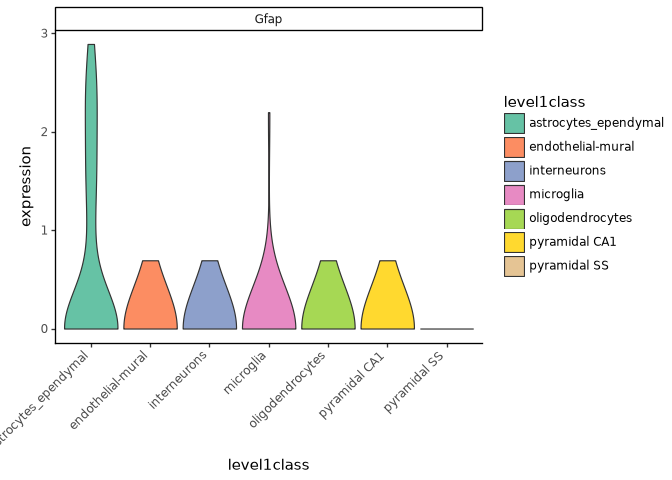

In [8]:
gg.plot_expression(plot_df, features=["Gfap"], group_by="level1class", log1p=True)

## 5. Plotting from the `SingleCellExperiment` directly

The same call accepts the SCE directly. Its registered adapter retrieves
the assay and column data before delegating to the DataFrame
implementation:

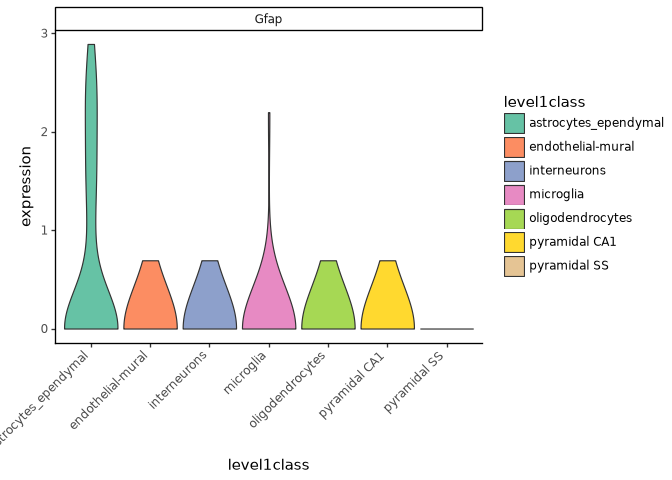

In [9]:
gg.plot_expression(zeisel, features=["Gfap"], group_by="level1class", log1p=True)

## 6. Converting to `AnnData` and plotting again

BiocPy containers convert to AnnData with a public `.to_anndata()`
method:

In [10]:
adata, _alt_exps = zeisel.to_anndata()
adata

AnnData object with n_obs × n_vars = 280 × 20006
    obs: 'tissue', 'group #', 'total mRNA mol', 'well', 'sex', 'age', 'diameter', 'level1class', 'level2class', 'rownames'
    var: 'featureType', 'rownames'
    layers: 'counts'

After this conversion, `to_anndata()` puts the assay into
`adata.layers["counts"]` and leaves `adata.X` as `None` (there was no
assay explicitly marked as the SCE’s primary “X” equivalent). ggnomics’s
AnnData adapter reads `.X` when `layer=None`. You can therefore pass
`layer="counts"` explicitly or assign the counts layer to `.X` after
conversion:

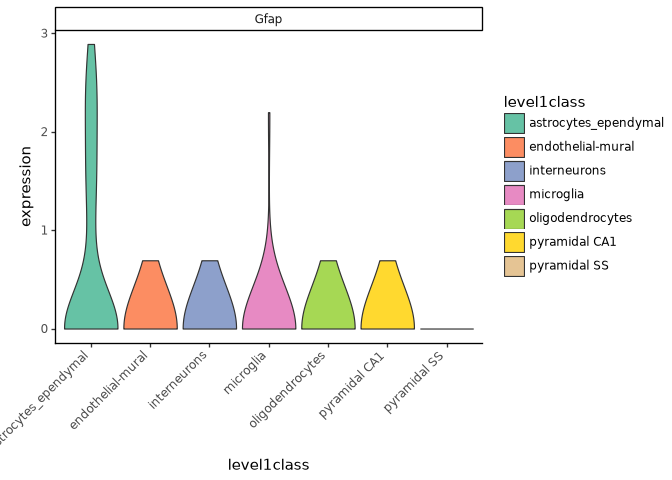

In [11]:
adata.X = adata.layers["counts"]
gg.plot_expression(adata, features=["Gfap"], group_by="level1class", log1p=True)

All three calls use the same underlying measurements and produce the
same plot.

## 7. How dispatch works

`plot_expression`, like the other public `plot_*` functions, is a
`functools.singledispatch` generic. The base DataFrame implementation
supplies the public docstring shown by `?gg.plot_expression`, `help()`,
and the API reference.

In [12]:
help(gg.plot_expression)

Help on function plot_expression in module ggnomics.expression:

plot_expression(data: 'pd.DataFrame', features: 'List[str]', group_by: 'str', layer: 'Optional[str]' = None, color_by: 'Optional[str]' = None, palette: 'Optional[Dict]' = None, ncol: 'Optional[int]' = None, log1p: 'bool' = False, add_points: 'bool' = False, point_size: 'Optional[float]' = None, title: 'Optional[str]' = None) -> 'ggplot'
    Violin plot of feature expression across cell/sample groups.

    Each ``feature`` becomes one facet panel; the x-axis shows ``group_by``
    categories and the y-axis shows expression level.

    Args:
        data: DataFrame whose rows are cells/samples. Requested ``features``
            and ``group_by``/``color_by`` are columns.
        features: Non-empty list of feature/gene column names to plot. Must
            not contain duplicates or collide with ``group_by``/``color_by``.
        group_by: Column whose categories define the x-axis groups.
        layer: Present for cross-co

Adapters for AnnData, `SingleCellExperiment`, `SummarizedExperiment`,
and `MuData` are registered when their corresponding packages are
available:

In [13]:
import ggnomics._backends as backends
backends._BACKENDS

{'anndata': 'ggnomics._backends.anndata',
 'singlecellexperiment': 'ggnomics._backends.singlecellexperiment',
 'summarizedexperiment': 'ggnomics._backends.summarizedexperiment',
 'mudata': 'ggnomics._backends.mudata'}

The core installation therefore works with DataFrames alone. Installing
`anndata` or one of the BiocPy containers makes the matching
implementation available without an additional registration step.

## 8. Inspecting and extending the returned object

Most `plot_*` functions return a `plotnine.ggplot`. Multi-panel and
matrix functions may instead return a `plotnine.composition.Compose` or
a small result object; these cases are listed in the [plot
gallery](plot-gallery.ipynb). For a `ggplot`, ordinary plotnine layers can
be added directly:

In [14]:
from plotnine import theme_bw, theme, labs, facet_wrap, element_text

p = gg.plot_expression(plot_df, features=["Gfap"], group_by="level1class", log1p=True)
type(p)

plotnine.ggplot.ggplot

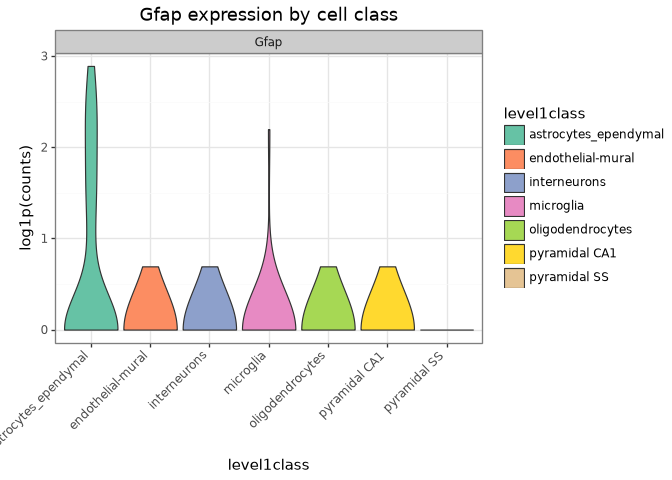

In [15]:
(
    p
    + labs(title="Gfap expression by cell class", y="log1p(counts)")
    + theme_bw()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

`plot_expression` facets over features. Its plotting data contain
`group_by`, `feature`, and `expression`, so an external `facet_wrap()`
can only use columns retained by that reshape. Pass several features to
use the built-in feature facets:

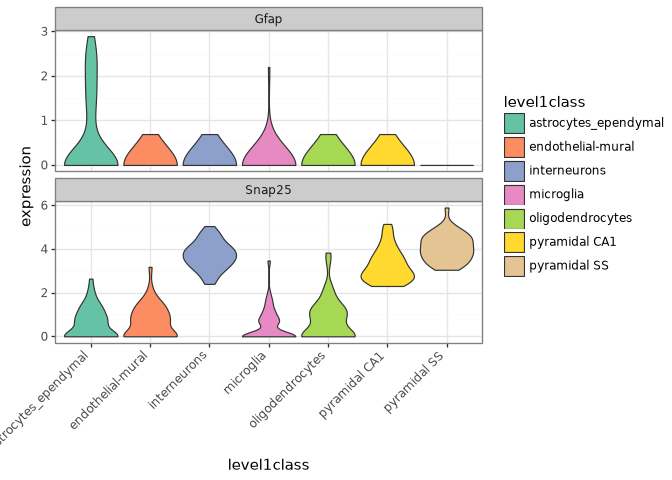

In [16]:
gg.plot_expression(
    plot_df.assign(Snap25=np.asarray(
        counts[list(gene_names).index("Snap25"), :].todense()
        if sp.issparse(counts) else counts[list(gene_names).index("Snap25"), :]
    ).ravel()),
    features=["Gfap", "Snap25"], group_by="level1class", log1p=True, ncol=1,
) + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1))

## 9. Saving a plot

Use plotnine’s `ggplot.save()` for a single panel. Multi-panel `Compose`
objects can be saved with `ggnomics.save_composition`, as shown under
[Composed panels](plot-gallery.ipynb#Composed-panels).

In [17]:
out_path = pathlib.Path("_freeze_assets")
out_path.mkdir(exist_ok=True)
p.save(out_path / "gfap_by_class.png", width=6, height=4, dpi=150, verbose=False)

## 10. Common errors

**Unknown column** — container adapters raise a `KeyError` when a
requested annotation is absent:

In [18]:
try:
    gg.plot_expression(plot_df, features=["Gfap"], group_by="not_a_real_column")
except KeyError as exc:
    print("KeyError:", exc)

KeyError: "Column(s) ['not_a_real_column'] not found in the DataFrame. Available: ['tissue', 'group #', 'total mRNA mol', 'well', 'sex', 'age', 'diameter', 'level1class', 'level2class', 'rownames', 'Gfap']"

**No stored embedding** — `plot_umap`, `plot_pca`, and
`plot_reduced_dim` require coordinates in the relevant reduced-dimension
slot. A plain `SummarizedExperiment`, or an SCE before dimensionality
reduction, cannot supply them:

In [19]:
try:
    gg.plot_umap(zeisel, color="level1class")
except (TypeError, KeyError, AttributeError) as exc:
    print(f"{type(exc).__name__}:", exc)

KeyError: "Embedding 'X_umap' not found in SCE reduced dimensions. Available: []"

(Zeisel has no stored UMAP/PCA — see [Single-cell analysis with
scranpy](single-cell-scranpy.ipynb) to compute one and make this call
succeed.)

**Optional package not installed** — an SCE, AnnData, or MuData
implementation is only registered when its container package is
importable. Without it, the generic function reports that no
implementation exists for the supplied type.

## Next steps

- [Single-cell analysis with scranpy](single-cell-scranpy.ipynb) — the
  full Zeisel dataset through QC → normalization → HVG → PCA →
  clustering → UMAP pipeline, with ggnomics plots at every stage.
- [Bulk RNA-seq](bulk-rnaseq.ipynb) — PyDESeq2 differential expression on
  a rice salt-stress experiment.
- [Multimodal](multimodal.ipynb) — RNA/ADT CITE-seq interoperability.
- [Specialized plots](specialized-plots.ipynb) and the [plot
  gallery](plot-gallery.ipynb) for everything else.